In [71]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn.externals.six import StringIO
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pydotplus
import matplotlib.pyplot as plt

df_diabetes = pd.read_csv("data/diabetes.csv")
label = 'Outcome'
df_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
x = df_diabetes.drop(columns=[label])
y = df_diabetes[label]
feature_cols = x.columns
diabetes_class_names = [str(v) for v in df_diabetes[label].unique()]
clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(x, y)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=3, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

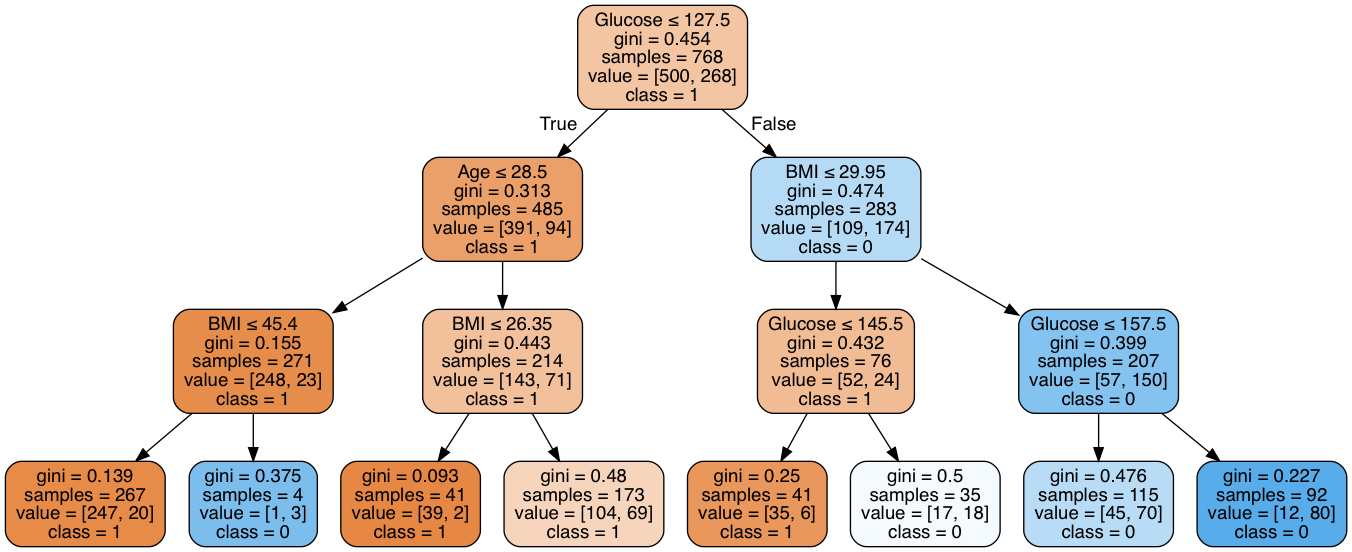

In [3]:
def plot_decision_tree(model, feature_cols, class_names):
    dot_data = StringIO()
    export_graphviz(model, out_file=dot_data, filled=True, rounded=True,
                    special_characters=True, feature_names=feature_cols, class_names=class_names)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    graph.write_png('diabetes.png')
    return Image(graph.create_png())
    
plot_decision_tree(clf, feature_cols, diabetes_class_names)

In [56]:
#df_insurance = pd.read_csv("data/MotorInsuranceFraudClaimABTFull.csv")
df_insurance = pd.read_csv("~/Desktop/MotorInsuranceFraudClaimABTFull.csv")

df_insurance.isna().sum()

ID                           0
Insurance Type               0
Income of Policy Holder      0
Marital Status             330
Num Claimants                0
Injury Type                  0
Overnight Hospital Stay      0
Claim Amount                 0
Total Claimed                0
Num Claims                   0
Num Soft Tissue             10
% Soft Tissue                0
Claim Amount Received        0
Fraud Flag                   0
dtype: int64

In [87]:
df_ins = df_insurance.copy()
label_insurance = "Fraud Flag"
#df_ins['Marital Status'].fillna('missing', inplace=True)
df_ins['Num Soft Tissue'].fillna(df_insurance['Num Soft Tissue'].mean(), inplace=True)
#df_ins['Insurance Type '] = df_ins['Insurance Type '].map({"CI": 0})
df_ins.drop(columns=['ID', 'Insurance Type ', 'Marital Status', 'Claim Amount Received'], inplace=True)
#df_insurance.dropna(inplace=True)
df_ins['Overnight Hospital Stay'] = df_insurance['Overnight Hospital Stay'].map({"No": 0, "Yes":1})
y_insurance = df_ins[label_insurance]
insurance_class_names = [str(v) for v in df_ins[label_insurance].unique()]
df_ins.drop(columns=[label_insurance], inplace=True)
feature_cols_insurance = df_ins.columns
ctg_cols = ['Injury Type']
x_insurance_dummy = pd.get_dummies(df_ins, columns=ctg_cols)
x_insurance_dummy

,Income of Policy Holder,Num Claimants,Overnight Hospital Stay,Claim Amount,Total Claimed,Num Claims,Num Soft Tissue,% Soft Tissue,Injury Type_Back,Injury Type_Broken Limb,Injury Type_Serious,Injury Type_Soft Tissue
0,0,2,0,1625,3250,2,2.000000,1.0,0,0,0,1
1,0,2,1,15028,60112,1,0.000000,0.0,1,0,0,0
2,54613,1,0,-99999,0,0,0.000000,0.0,0,1,0,0
3,0,3,1,270200,0,0,0.000000,0.0,0,0,1,0
4,0,4,0,8869,0,0,0.000000,0.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,1,0,2118,0,0,0.000000,0.0,0,0,0,1
496,29280,4,1,3199,0,0,0.234694,0.0,0,1,0,0
497,0,1,1,32469,0,0,0.000000,0.0,0,1,0,0
498,46683,1,0,179448,0,0,0.000000,0.0,0,1,0,0


In [ ]:
import seaborn as sns 

colormap = plt.cm.RdBu
f, axs = plt.subplots(1, 1, figsize=(8, 8))
#ax = plt.subplot(3, 3, idx + 1)
sns.heatmap(ms_nn.corr(method='pearson', min_periods=1).round(decimals=2), linewidths=0.1, vmax=1.0, square=True,
            cmap=colormap, linecolor='white', annot=True)
#plt.xticks(rotation=30, fontsize=7)
plt.show()

Accuracy: 0.6444444444444445


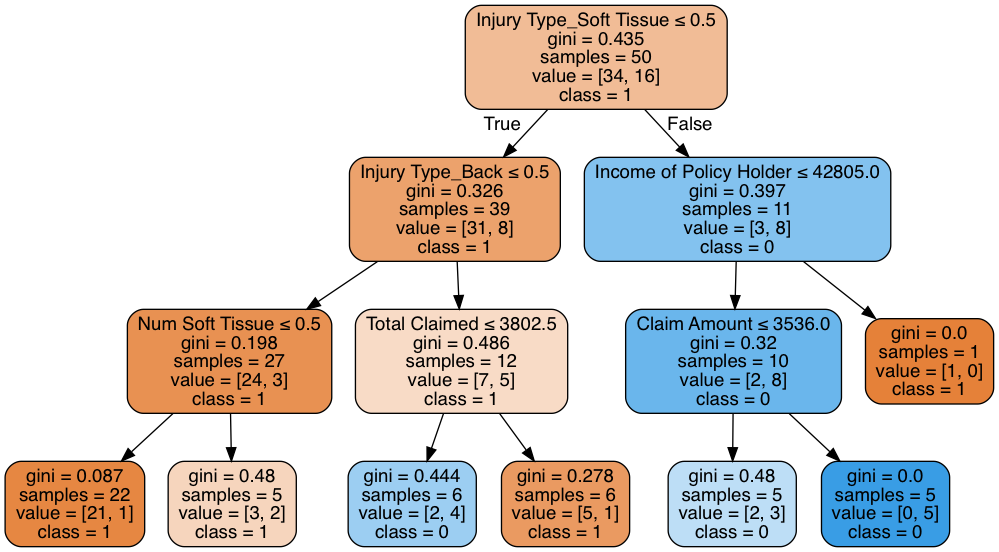

In [88]:
x_train, x_test, y_train, y_test = train_test_split(x_insurance_dummy, y_insurance, test_size=0.9, random_state=1)

clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
plot_decision_tree(clf, x_insurance_dummy.columns, insurance_class_names)

Accuracy: 0.6444444444444445


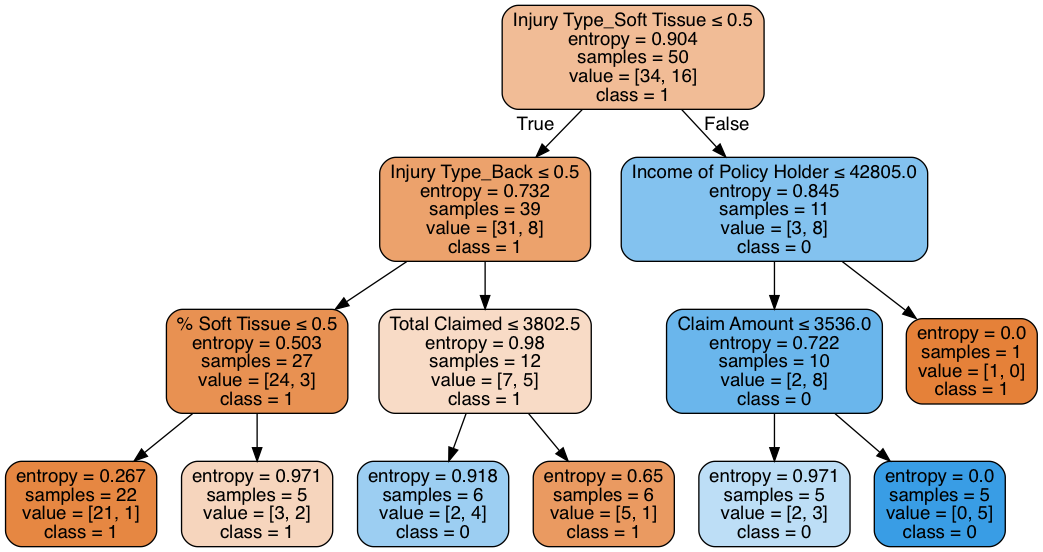

In [89]:
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3)
clf_entropy.fit(x_train, y_train)
y_pred_2 = clf_entropy.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_2))
plot_decision_tree(clf_entropy, x_insurance_dummy.columns, insurance_class_names)

Accuracy: 0.7266666666666667


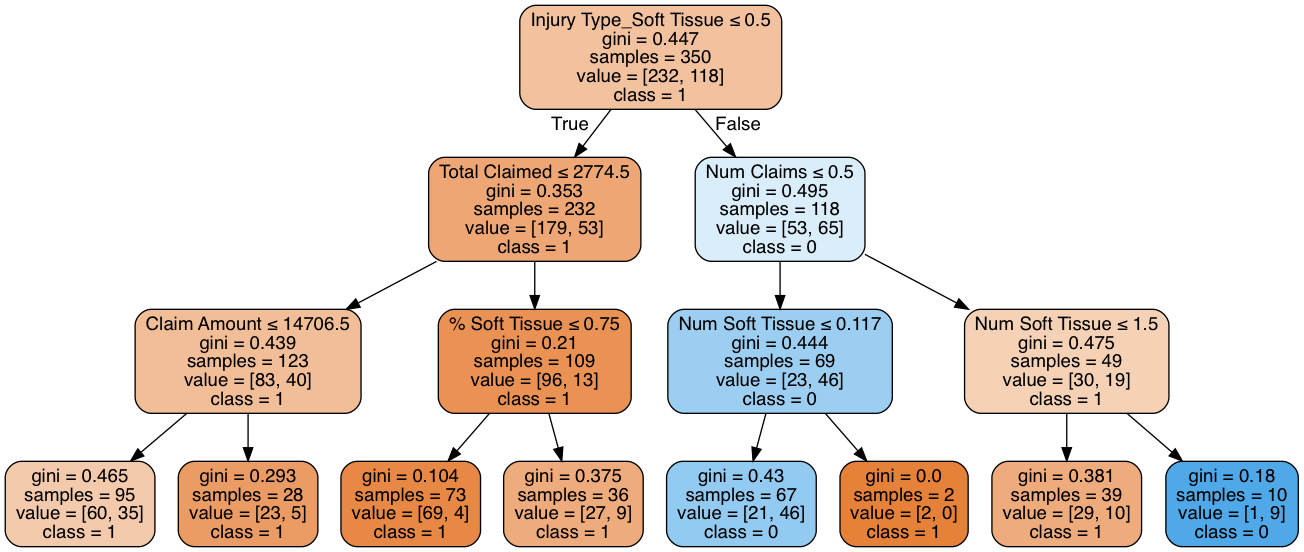

In [90]:
x_train, x_test, y_train, y_test = train_test_split(x_insurance_dummy, y_insurance, test_size=0.3, random_state=1)
clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
plot_decision_tree(clf, x_insurance_dummy.columns, insurance_class_names)

Accuracy: 0.7


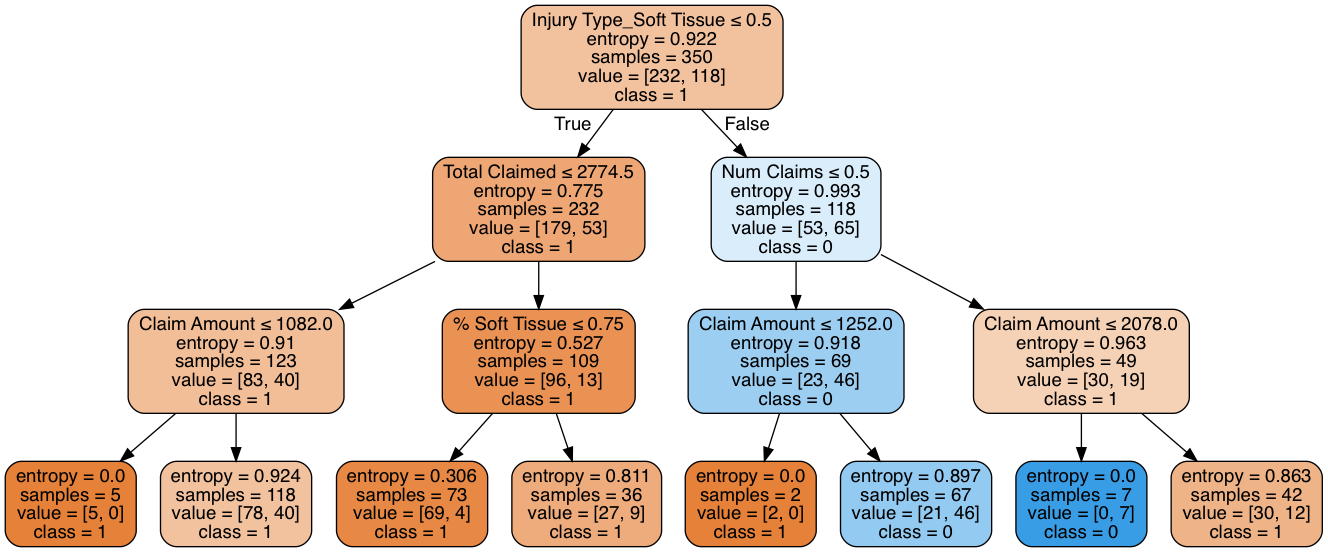

In [91]:
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3)
clf_entropy.fit(x_train, y_train)
y_pred_2 = clf_entropy.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_2))
plot_decision_tree(clf_entropy, x_insurance_dummy.columns, insurance_class_names)

In [83]:
from sklearn.feature_selection import mutual_info_classif
dict(zip(x_train.columns,
               mutual_info_classif(x_train, y_train, discrete_features=True)
               ))

{'ID': 0.639122137587653,
 'Income of Policy Holder': 0.20980924253338928,
 'Num Claimants': 0.004730781258860797,
 'Overnight Hospital Stay': 0.01198070325178896,
 'Claim Amount': 0.6232787734605685,
 'Total Claimed': 0.2675559217765308,
 'Num Claims': 0.06022078741391032,
 'Num Soft Tissue': 0.020159370009598197,
 '% Soft Tissue': 0.03103992784460028,
 'Injury Type_Back': 0.0004003219884247955,
 'Injury Type_Broken Limb': 0.019465508328298464,
 'Injury Type_Serious': 0.019414484601115608,
 'Injury Type_Soft Tissue': 0.050963048192520954}

[0.68, 0.7266666666666667, 0.7066666666666667, 0.6933333333333334, 0.68, 0.6466666666666666, 0.6333333333333333, 0.6, 0.6, 0.5933333333333334, 0.5933333333333334, 0.6066666666666667, 0.6, 0.6133333333333333, 0.6, 0.5933333333333334, 0.5866666666666667, 0.5933333333333334, 0.6066666666666667, 0.6, 0.5866666666666667, 0.5933333333333334, 0.58, 0.5666666666666667]


([<matplotlib.axis.XTick at 0x1206f5ee0>,
 <a list of 24 Text xticklabel objects>)

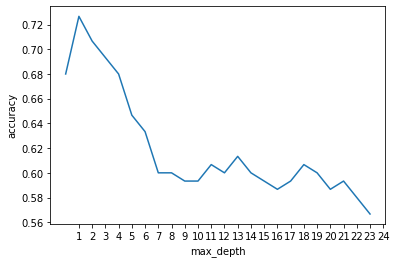

In [92]:
depths = range(1, 25)
accuracies = []
for depth in depths:
    clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=depth)
    clf_entropy.fit(x_train, y_train)
    y_pred = clf_entropy.predict(x_test)
    accuracies.append(accuracy_score(y_test, y_pred))
print(accuracies)

#f, axs = plt.subplots(1, 1, figsize=(8, 8))
plt.plot(accuracies)
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.xticks(np.arange(1, 25, 1))

#plot_decision_tree(clf_entropy, x_insurance_dummy.columns, insurance_class_names)